## Machine Learning analysis on California Housing dataset

In [19]:
# importing dataset
import numpy as np
import pandas as pd
df = pd.read_csv("housing.csv")

In [2]:
df.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
df.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [5]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [4]:
df.shape

(20640, 10)

In [4]:
df['ocean_proximity'].value_counts()

ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64

### Feature Engineering

In [6]:
df['rooms_per_household'] = df['total_rooms'] / df['households']
df['bedrooms_per_room'] = df['total_bedrooms'] / df['total_rooms']
df['population_per_household'] = df['population'] / df['households']

### Data cleaning

In [7]:
from sklearn.impute import SimpleImputer

In [8]:
imputer = SimpleImputer(strategy='median')
df['total_bedrooms'] = imputer.fit_transform(df[['total_bedrooms']])
df['bedrooms_per_room'] = imputer.fit_transform(df[['bedrooms_per_room']])

In [9]:
# encoding categorical data
df_encoded = pd.get_dummies(df, columns=['ocean_proximity'])

### Feature and target value selection

In [10]:
X = df_encoded.drop('median_house_value', axis=1)
y = df_encoded['median_house_value']

In [11]:
# splitting data into train and test set
from sklearn.model_selection import train_test_split

In [12]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Scaling features value

In [13]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler

In [14]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Model training 

In [15]:
from sklearn.ensemble import RandomForestRegressor

In [16]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train_scaled, y_train)

RandomForestRegressor(n_jobs=-1, random_state=42)

### Evaluation

In [17]:
from sklearn.metrics import mean_squared_error, r2_score

In [20]:
y_pred = rf_model.predict(X_test_scaled)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

In [21]:
print(f"RMSE: {rmse:.2f}")
print(f"R2 Score: {r2:.4f}")

RMSE: 49829.45
R2 Score: 0.8105


### Feature Importance

In [22]:
feature_importances = rf_model.feature_importances_
feature_names = X.columns
importance_df = pd.DataFrame({'feature': feature_names, 'importance': feature_importances}).sort_values('importance', ascending=False)

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

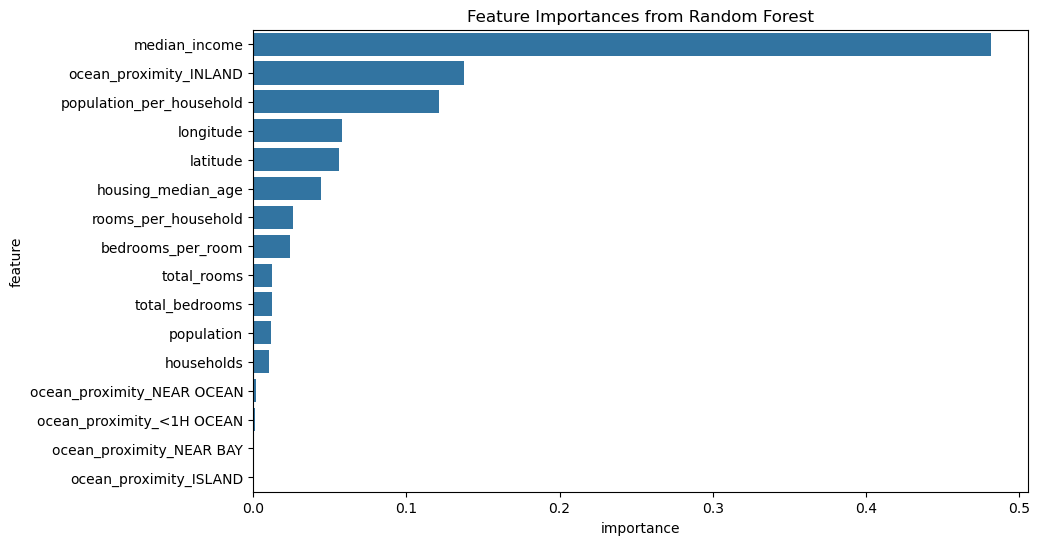

In [25]:
plt.figure(figsize=(10, 6))
sns.barplot(x='importance', y='feature', data=importance_df)
plt.title('Feature Importances from Random Forest')
plt.savefig('visuals/feature_importance.png')

### Actual vs predicted plot

<Figure size 640x480 with 0 Axes>

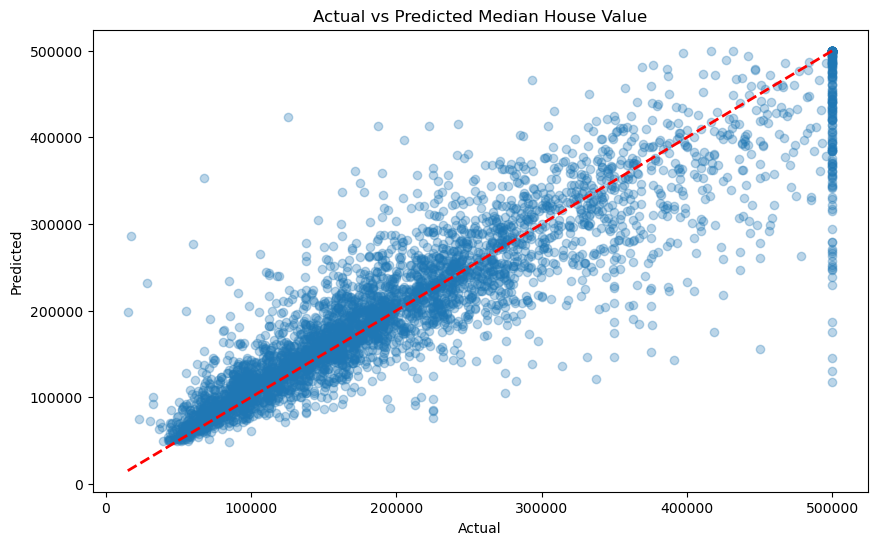

In [26]:
plt.clf()
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, alpha=0.3)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title('Actual vs Predicted Median House Value')
plt.savefig('visuals/actual_vs_predicted.png')

In [27]:
# top 10 important features
top_features = importance_df.head(10)
print("Top 10 Important Features:")
top_features

Top 10 Important Features:


,feature,importance
7,median_income,0.481545
12,ocean_proximity_INLAND,0.137497
10,population_per_household,0.121444
0,longitude,0.057863
1,latitude,0.056255
2,housing_median_age,0.044235
8,rooms_per_household,0.025800
9,bedrooms_per_room,0.024228
3,total_rooms,0.012678
4,total_bedrooms,0.012304


In [28]:
# checking correlation matrix for the target variable
corr_matrix = df.corr(numeric_only=True)
print("\nCorrelation with median_house_value:")
print(corr_matrix['median_house_value'].sort_values(ascending=False))


Correlation with median_house_value:
median_house_value    1.000000
median_income         0.688075
total_rooms           0.134153
housing_median_age    0.105623
households            0.065843
total_bedrooms        0.049686
population           -0.024650
longitude            -0.045967
latitude             -0.144160
Name: median_house_value, dtype: float64
